In [1]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

from numba import njit, int64
from numba.typed import Dict
from numba.types import UniTuple

from matplotlib.ticker import NullLocator

In [2]:
## constants/settings:

## physical units: time --> years, mass --> Msun, distance --> pc
## physical unit conversion
## integrator runs in G = 1 code units
## these factors convert displayed quantities to real SI / astrophysical values for the HUD labels.
G = 1.0
G_si = 6.67e-11             ## (m^3 kg^-1 s^-2)
pc_m = 3.0857e16            ## (meters per parsec)
msun_kg = 1.989e30          ## (Msun to kg)
year_s = 365.25 * 86400     ## (seconds per year)

## particle setup:
particles_per_dimension = 16
n_particles = particles_per_dimension ** 3
tot_dm_mass = 1e9           ## Msun (total mass distributed evenly across all particles)
particle_mass = tot_dm_mass / n_particles
mass = np.full(n_particles, particle_mass)

## box setup
sphere_radius = 2e4                             ## 20 kpc initial "virialized" sphere radius 
box_size = 1.5 * sphere_radius                  ## half-box width, pc
volume = (4.0/3.0) * np.pi * sphere_radius**3
number_density = n_particles / volume
mean_spacing = number_density ** (-1.0 / 3.0)
softening = 0.1 * mean_spacing                  ## gravitational softening length, pc

## dissipation
r_coll = 1.25 * softening        ## collision radius, minimum distance that particles can approach before "scattering"
epsilon = 0                      ## epsilon = 0 --> elastic scattering, no energy lost
## epsilon = 0.00001             ## epsilon < 0 --> inelastic scattering, tiny amount of energy lost

#################################################################################################################################

## simulation settings

## integration (with adaptive timestepping)
t_end = 93.0           ## one dynamical time is ~ 93 
eta_acc = 0.1          ## safety factor, acceleration-based criterion
eta_vel = 0.1          ## safety factor, velocity-based criterion (collision-skip prevention)
dt_min = 1e-4          ## floor, code time units
dt_max = 0.1           ## ceiling, code time units -- your old fixed dt

## rendering
plot_every = 5           ## rendering frequency
energy_every = 5         ## energy calculation frequency, for tracking total energy

gif_path = "dissipation_v5.gif"
gif_duration = 100       ## how long each frame is shown for

marker_scale = 0.00001

## converting from code units to physical time/energy
time_unit_s = np.sqrt(pc_m**3 / (G_si * msun_kg))       ## 1 simulation time unit to physical seconds conversion
time_unit_yr = time_unit_s / year_s                     ## years per 1 code time unit
energy_unit_j = G_si * msun_kg**2 / pc_m                ## Joules per 1 code energy unit

#######################################################################################################################

## NFW reference profile
## parameterized by scale radius r_s --> rho_s calculated from tot_dm_mass and r_s
## this is the attractor profile that pure-gravity CDM halos relax toward

## NFW scale radius (smaller --> more cuspy reference)
## defined as the point where d(lnρ)/d(lnr) = ~ -2
r_s = sphere_radius / 12.0          ## ≈ 1667 pc, c ≈ 12
nfw_c = sphere_radius / r_s         ## sphere_radius --> R200 or Rvir

## computed from the definition of the NFW profile
## density within a sphere of radius r_s
rho_s = tot_dm_mass / (4 * np.pi * r_s**3 * (np.log(1 + nfw_c) - nfw_c/(1 + nfw_c)))

def nfw_density(r):
    nfw_fraction = r / r_s
    return rho_s / ((nfw_fraction) * (1 + nfw_fraction)**2)

cell_key_type = UniTuple(int64, 3)

In [3]:
## physics functions

## place particles uniformly by volume inside a sphere
def generate_sphere_points(num_points, radius = sphere_radius):

    print("Generating sphere of particles...")

    ## 1. generate uniform random variables for angles and radius scaling
    u = np.random.uniform(0, 1, num_points)
    phi = np.random.uniform(0, 2 * np.pi, num_points)    ## azimuthal angle
    costheta = np.random.uniform(-1, 1, num_points)      ## cos(polar angle) --> pi/2 to -pi/2

    ## 2. calculate coordinates (Cartesian to spherical)
    theta = np.arccos(costheta)
    r = radius * (u ** (1/3))     ## Cube root to prevent the points crowding toward the center

    ## 3. convert to Cartesian (x, y, z)
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)

    ## stack particles
    particle_stack = np.column_stack((x, y, z))

    return particle_stack

## pairwise gravitational acceleration
## softening**2 term in the denominator prevents infinite force when particles get too close ("Plummer-softening")

@njit(fastmath = True)
def get_accel(pos, mass, softening, G):

    N = pos.shape[0]
    accel = np.zeros((N, 3))

    soft2 = softening*softening

    for i in range(N - 1):

        xi = pos[i, 0]
        yi = pos[i, 1]
        zi = pos[i, 2]

        for j in range(i + 1, N):

            dx = pos[j, 0] - xi
            dy = pos[j, 1] - yi
            dz = pos[j, 2] - zi

            r2 = dx*dx + dy*dy + dz*dz + soft2
            inv_r3 = 1.0/(r2*np.sqrt(r2))

            ## N3L --> force on i from j uses m_j, force on j from i uses m_i
            fac_i = G * mass[j] * inv_r3
            fac_j = G * mass[i] * inv_r3

            accel[i, 0] += dx * fac_i
            accel[i, 1] += dy * fac_i
            accel[i, 2] += dz * fac_i

            accel[j, 0] -= dx * fac_j
            accel[j, 1] -= dy * fac_j
            accel[j, 2] -= dz * fac_j

    return accel

## total KE and PE of the system
@njit(fastmath = True)
def get_energy(pos, vel, mass, softening):

    N = pos.shape[0]

    KE = 0.0
    PE = 0.0

    ## kinetic energy
    for i in range(N):

        vx = vel[i, 0]
        vy = vel[i, 1]
        vz = vel[i, 2]

        KE += 0.5 * mass[i] * (vx*vx + vy*vy + vz*vz)

    ## potential energy
    for i in range(N - 1):

        xi = pos[i, 0]
        yi = pos[i, 1]
        zi = pos[i, 2]

        for j in range(i + 1, N):

            dx = pos[j, 0] - xi
            dy = pos[j, 1] - yi
            dz = pos[j, 2] - zi

            r = np.sqrt(dx*dx + dy*dy + dz*dz + softening*softening)

            PE -= mass[i] * mass[j] / r

    return KE, PE

## sample velocities from a Maxwell-Boltzmann distribution
## velocities calibrated so that the system starts near virial equilibirum
## sigma solved from the virial theorem

def init_maxwell_boltzmann_velocities(pos, mass, num_points):
    
    _, PE = get_energy(pos, np.zeros_like(pos), mass, softening)
    target_KE = abs(PE) / 2.0                                 # virial theorem

    ## equipartition theorem says that each degree of freedom has 1/2 * kB * T
    ## each particle thus has 3/2 * kB * T and sum of all particles' KE = 1/2 M <v^2>, these are equal
    ## <v^2> = 3*kB*T / M --> v_rms = sqrt(3 * kB * T / M)
    v_rms = np.sqrt(target_KE / tot_dm_mass)

    ## initializing slightly out of virial equilibrium --> deliberately starting slightly "cold"
    #sigma = 1.0 * v_rms

    ## initializing in perfect virial equilibrium
    sigma = v_rms

    ## sample velocity distribution
    v_x = np.random.normal(0, sigma, num_points)
    v_y = np.random.normal(0, sigma, num_points)
    v_z = np.random.normal(0, sigma, num_points)

    vel = np.column_stack((v_x, v_y, v_z))

    ## move to COM frame
    com_vel = np.sum(mass[:, None] * vel, axis = 0) / np.sum(mass)   ## (3,) vector
    vel -= com_vel
    
    return vel

## log-space kernel density estimator (KDE).
## instead of hard bins (noisy at N=1000), place a Gaussian kernel on each particle in log(r) space and evaluate the sum at each r_eval point.
## the 1/(4*pi*r^3) factor converts the log-r KDE to a 3D mass density.
## bandwidth = 2 * Scott's rule (slightly over-smoothed for visual clarity).
## eval points outside the actual particle support are masked NaN.

def get_density_profile(pos, mass):
    
    center = np.mean(pos, axis = 0)
    r = np.linalg.norm(pos - center, axis = 1)
    r = np.maximum(r, softening)
    log_r = np.log(r)
    r_min, r_max = r.min(), r.max()
 
    bw = kde_bw_factor * 1.06 * log_r.std() * n_particles**(-0.2)   # Scott's rule in log-r
 
    log_r_eval = np.log(density_bin_centers)
    diff = (log_r_eval[:, None] - log_r[None, :]) / bw              # (n_bins, n_particles)
    kde = np.exp(-0.5 * diff**2).sum(axis = 1) / (bw * np.sqrt(2 * np.pi) * n_particles)
 
    rho = (kde * n_particles * particle_mass) / (4 * np.pi * density_bin_centers**3)
 
    # mask eval points outside the actual particle support range
    in_support = (density_bin_centers >= r_min * 0.5) & (density_bin_centers <= r_max * 1.5)
    
    return np.where(in_support, rho, np.nan)

## pre-compute fixed density binning (done once at module load, outside main)
n_density_bins = 30
density_bin_edges = np.logspace(np.log10(softening), np.log10(box_size), n_density_bins + 1)
density_bin_centers = np.sqrt(density_bin_edges[:-1] * density_bin_edges[1:])   # geometric mean per bin
kde_bw_factor = 2.0   # bandwidth multiplier on Scott's rule; increase to smooth more

## collisions
## for two particles colliding

@njit(fastmath = True)
def resolve_collisions(pos, vel, mass, r_coll, epsilon):

    N = pos.shape[0]
    r_coll2 = r_coll * r_coll

    n_collisions = 0

    for i in range(N - 1):

        xi = pos[i, 0]
        yi = pos[i, 1]
        zi = pos[i, 2]

        vxi = vel[i, 0]
        vyi = vel[i, 1]
        vzi = vel[i, 2]

        mi = mass[i]

        for j in range(i + 1, N):

            dx = pos[j, 0] - xi
            dy = pos[j, 1] - yi
            dz = pos[j, 2] - zi

            r2 = dx*dx + dy*dy + dz*dz

            if r2 < r_coll2  and r2 > 0.0:

                r = np.sqrt(r2)
                nx = dx / r
                ny = dy / r
                nz = dz / r    ## unit vector i --> j

                ## relative velocity along line of centers
                dvx = vxi - vel[j, 0]
                dvy = vyi - vel[j, 1]
                dvz = vzi - vel[j, 2]

                v_rel_n = dvx*nx + dvy*ny + dvz*nz

                ## only resolve if approaching (v_rel_n < 0 means i moving toward j)
                if v_rel_n < 0.0:

                    mj = mass[j]
                    m_tot = mi + mj

                    ## mass-weighted impulse coefficients (elastic, momentum + KE conserving)
                    ci = 2.0 * mj / m_tot
                    cj = 2.0 * mi / m_tot

                    vxi -= ci * v_rel_n * nx
                    vyi -= ci * v_rel_n * ny
                    vzi -= ci * v_rel_n * nz

                    vel[j, 0] += cj * v_rel_n * nx
                    vel[j, 1] += cj * v_rel_n * ny
                    vel[j, 2] += cj * v_rel_n * nz

                    n_collisions += 1

        vel[i, 0], vel[i, 1], vel[i, 2] = vxi, vyi, vzi

    return n_collisions

## adaptive timestepping based on the acceleration and velocity:
@njit(fastmath = True)
def get_adaptive_dt(vel, acc, softening, eta_acc, eta_vel, dt_min, dt_max):

    N = vel.shape[0]
    dt_new = dt_max

    for i in range(N):

        a_mag = np.sqrt(acc[i,0]*acc[i,0] + acc[i,1]*acc[i,1] + acc[i,2]*acc[i,2])
        v_mag = np.sqrt(vel[i,0]*vel[i,0] + vel[i,1]*vel[i,1] + vel[i,2]*vel[i,2])

        if a_mag > 0.0:
            dt_acc = eta_acc * np.sqrt(softening / a_mag)
            if dt_acc < dt_new:
                dt_new = dt_acc

        if v_mag > 0.0:
            dt_vel = eta_vel * softening / v_mag
            if dt_vel < dt_new:
                dt_new = dt_vel

    if dt_new < dt_min:
        dt_new = dt_min
    if dt_new > dt_max:
        dt_new = dt_max

    return dt_new

Generating sphere of particles...
Box: 30000.0 pc | Sphere radius: 20000.0 pc
Total DM mass: 1.00e+09 Msun | Particle mass: 2.44e+05 Msun
Softening: 201.499 pc | r_coll: 251.874 pc | epsilon: 0
dt_min: 1.0e-04 (1491.24 yr) | dt_max: 1.0e-01 (1491236 yr) | t_end: 1386.85 Myr
Step 2589 | t = 1386.8491 / 1386.8491 Myr | dt = 2.53e-02
GIF created and saved at dissipation_v5.gif
E[0] = -7.893633e+12, E[-1] = -7.893744e+12, |ΔE| = 1.117375e+08
Total Energy Change: 0.001%
Total steps: 2,589 | Total collisions: 1,320,028 | avg per step: 509.9
dt_min hit on 0 steps (0.0% of steps)


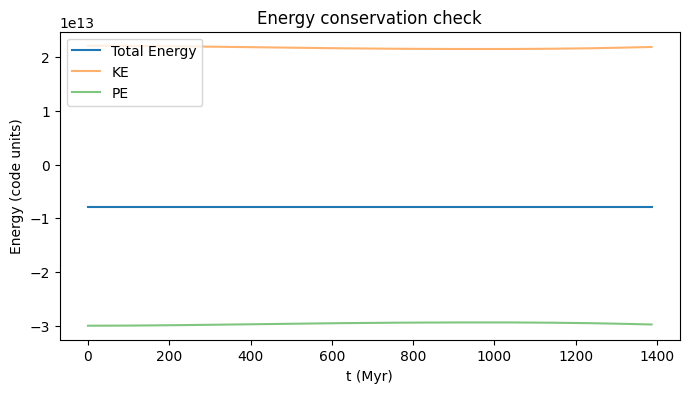

In [26]:
## simulation driver:

def main():
    
    np.random.seed(0)  # reproducible runs; remove/change for variation

    pos = generate_sphere_points(n_particles, sphere_radius)
    vel = init_maxwell_boltzmann_velocities(pos, mass, n_particles)

    print(f"Box: {box_size} pc | Sphere radius: {sphere_radius:.1f} pc")
    print(f"Total DM mass: {tot_dm_mass:.2e} Msun | Particle mass: {particle_mass:.2e} Msun")
    print(f"Softening: {softening:.3f} pc | r_coll: {r_coll:.3f} pc | epsilon: {epsilon}")
    print(f"dt_min: {dt_min:.1e} ({dt_min * time_unit_yr:.2f} yr) | dt_max: {dt_max:.1e} ({dt_max * time_unit_yr:.0f} yr) | t_end: {t_end * time_unit_yr / 1e6:.2f} Myr")

    acc = get_accel(pos, mass, softening, G)

    ## initial energy calculation
    KE, PE = get_energy(pos, vel, mass, softening)

    last_KE = KE
    last_PE = PE

    ## energy history only contains actual calculations
    save_KE = [KE]
    save_PE = [PE]
    save_time = [0.0]

    ## per-frame collision history (one entry per captured frame):
    ## coll_per_frame: how many collision events occurred in the steps since the last frame
    ## coll_cumulative: running total up to and including this frame
    ## t_frame_myr: physical time in Myr at the moment the frame was captured
    coll_per_frame = []
    coll_cumulative = []
    t_frame_myr = []

    ## figure: three panels
    ## left (large): particle scatter, x-y projection
    ## top-right: radial density profile vs NFW reference
    ## bottom-right: collision history (per-frame count + cumulative)
    ## built once, reused every frame
    fig = plt.figure(figsize = (12, 6), constrained_layout = True)
    axs = fig.subplot_mosaic([['main', 'density'], ['main', 'collisions']], gridspec_kw = {'width_ratios': [3, 2], 'height_ratios': [3, 2]})
    fig.suptitle(f"Dark Matter Core Collapse: ({n_particles} particles)", fontsize = 11)
 
    ## particle panel
    ax = axs['main']
    ax.set_xlim(-box_size, box_size)
    ax.set_ylim(-box_size, box_size)
    scat = ax.scatter(pos[:, 0], pos[:, 1], s = marker_scale * mass, color = 'tab:blue', alpha = 0.5, linewidths = 0, animated = True)
    title_text = ax.text(0.5, 1.02, "t = 0.00 Myr", transform = ax.transAxes, ha = "center", va = "bottom", fontsize = 10, animated = True)

    ## HUD text (energy diagnostics, displayed in physical units)
    txt_KE = ax.text(-box_size + 2, 0.90 * box_size, "", fontsize = 7, color = "#de0000", animated = True)
    txt_PE = ax.text(-box_size + 2, 0.80 * box_size, "", fontsize = 7, color = "#1637cc", animated = True)
    txt_ratio = ax.text(-box_size + 2, 0.70 * box_size, "", fontsize = 7, color = "#7516cc", animated = True)
    txt_Etot = ax.text(-box_size + 2, 0.60 * box_size, "", fontsize = 7, color = "black", animated = True)
    txt_coll = ax.text(-box_size + 2, 0.50 * box_size, "", fontsize = 7, color = "black", animated = True)
    txt_dt = ax.text(-box_size + 2, 0.40 * box_size, "", fontsize = 7, color = "#c41f67", animated = True)

    ## density profile panel
    dax = axs['density']
    dax.set_xscale('log')
    dax.xaxis.set_minor_locator(NullLocator())
    dax.set_yscale('log')
    dax.set_xlabel("r (pc)", fontsize = 8)
    dax.set_ylabel(r"$\rho\ \mathrm{(M_\odot\ pc^{-3})}$", fontsize = 8)
    dax.set_title("Radial Density Profile", fontsize = 9)
    dax.tick_params(labelsize = 7)

    nfw_reference = nfw_density(density_bin_centers)
    dax.plot(density_bin_centers, nfw_reference, linestyle = '--', color = 'gray', alpha = 0.8, linewidth = 1.2, label = f'NFW (rₛ = {r_s} pc)')
 
    init_density = get_density_profile(pos, mass)
    density_line, = dax.plot(density_bin_centers, init_density, color = 'tab:red', linewidth = 1.5, label = 'current ρ(r)', animated = True)
    dax.set_xlim(10, 100)
    dax.set_ylim(nfw_reference.min() * 0.1, nfw_reference.max() * 100)
    dax.legend(fontsize = 7, loc = 'upper right')

    ## collision history panel
    cax = axs['collisions']
    cax.set_xlabel("t (Myr)", fontsize = 8)
    cax.set_ylabel("collisions / frame", fontsize = 8, color = '#035afc')
    cax.tick_params(axis = 'y', labelcolor = '#035afc', labelsize = 7)
    cax.tick_params(axis = 'x', labelsize = 7)
    cax.set_title("Collisions", fontsize = 9)

    ## cumulative count on a secondary y-axis so both series are visible
    cax2 = cax.twinx()
    cax2.set_ylabel("cumulative", fontsize = 8, color = 'tab:purple')
    cax2.tick_params(axis = 'y', labelcolor = 'tab:purple', labelsize = 7)
 
    ## live line artists --> data grows frame by frame
    coll_rate_line, = cax.plot([], [], color = '#035afc', linewidth = 1.2, label = 'per frame', animated = True)
    coll_cum_line,  = cax2.plot([], [], color = '#8e3bdb', linewidth = 1.0, linestyle = '--', label = 'cumulative', animated = True)
 
    ## seed the first frame values so axes have something to scale from
    coll_per_frame.append(0)
    coll_cumulative.append(0)
    t_frame_myr.append(0.0)

    ## helper functions

    ## update all text labels and the title with current physical-unit values
    def update_hud(t_myr, KE, PE, total_coll, dt_i):

        title_text.set_text(f"t = {t_myr:.2f} Myr")
        txt_KE.set_text(f"KE: {KE * energy_unit_j:.2e} J")
        txt_PE.set_text(f"PE: {PE * energy_unit_j:.2e} J")
        txt_ratio.set_text(f"KE/PE: {KE / PE:.2f}")
        txt_Etot.set_text(f"E_tot: {(KE + PE) * energy_unit_j:.2e} J")
        txt_coll.set_text(f"Total Collisions: {total_coll:,}")
        txt_dt.set_text(f"dt: {dt_i:.2e} ({dt_i * time_unit_yr:.1f} yr)")

    ## push the latest per-frame and cumulative counts into the live line artists.
    ## rescale both axes to keep the full history visible without fixed limits
    ## (the range will grow as collapse accelerates and the rate increases).
    def update_collision_panel():

        t_arr = np.array(t_frame_myr)
        rate = np.array(coll_per_frame)
        cumul = np.array(coll_cumulative)
    
        coll_rate_line.set_data(t_arr, rate)
        coll_cum_line.set_data(t_arr, cumul)

        if t_arr[-1] > 0:
            xmax = t_arr[-1]
            cax.set_xlim(0, xmax)
            cax2.set_xlim(0, xmax)

        ## rescale y-axes to current data range, with headroom so lines don't touch the top
        rate_max = rate.max() if rate.size > 0 else 0
        cumul_max = cumul.max() if cumul.size > 0 else 0

        cax.set_ylim(0, max(rate_max * 1.15, 1))     ## floor of 1 avoids a degenerate (0,0) range at t=0
        cax2.set_ylim(0, max(cumul_max * 1.15, 1))

        fig.canvas.draw()

        for name, axis in all_axes.items():
            backgrounds[name] = fig.canvas.copy_from_bbox(axis.bbox)

    def capture_frame():

        canvas = fig.canvas
    
        # restore static backgrounds
        for name, axis in all_axes.items():
            canvas.restore_region(backgrounds[name])
    
        # redraw animated artists only
        for artist in animated_artists:
            artist.axes.draw_artist(artist)
    
        # blit updated regions
        for name, axis in all_axes.items():
            canvas.blit(axis.bbox)
    
        # copy rendered frame
        buf = np.asarray(canvas.buffer_rgba())
        frames.append(np.asarray(buf[:, :, :3], dtype = np.uint8).copy())

    ## initial frame (t=0, before any stepping)
    frames = []
    total_collisions = 0
    step_collisions = 0      ## collisions accumulated since the last captured frame
    
    # mark animated artists
    animated_artists = [scat, title_text, txt_KE, txt_PE, txt_ratio, txt_Etot, txt_coll, txt_dt, density_line, coll_rate_line, coll_cum_line]
    
    for artist in animated_artists:
        artist.set_animated(True)

    all_axes = {**axs, "collision_secondary": cax2}
    
    fig.canvas.draw()

    backgrounds = {name: fig.canvas.copy_from_bbox(axis.bbox) for name, axis in all_axes.items()}

    update_hud(0.0, last_KE, last_PE, total_collisions, dt_max)
    update_collision_panel()
    
    # update first frame
    capture_frame()
    
    ## LEAPFROG + DISSIPATION, ADAPTIVE TIMESTEP

    t_code = 0.0         ## elapsed simulation time, code units
    step_i = 0           ## step counter (variable now, since dt varies)
    min_dt_hits = 0      ## diagnostic: how often the dt floor gets hit -- frequent hits mean even dt_min isn't resolving the dynamics

    while t_code < t_end:

        dt_i = get_adaptive_dt(vel, acc, softening, eta_acc, eta_vel, dt_min, dt_max)

        if dt_i <= dt_min:
            min_dt_hits += 1

        ## don't overshoot dt on the final step
        if t_code + dt_i > t_end:
            dt_i = t_end - t_code

        ## leapfrog kick-drift-kick
        vel += (acc * dt_i) / 2.0
        pos += (vel * dt_i)
        acc = get_accel(pos, mass, softening, G)
        vel += (acc * dt_i) / 2.0

        n_coll = resolve_collisions(pos, vel, mass, r_coll, epsilon)
        total_collisions += n_coll
        step_collisions += n_coll

        t_code += dt_i
        step_i += 1

        t_myr = t_code * time_unit_yr / 1e6

        print(f"Step {step_i} | t = {t_myr:.4f} / {t_end * time_unit_yr / 1e6:.4f} Myr | dt = {dt_i:.2e}", end = "\r", flush = True)

        if step_i % energy_every == 0:
 
            KE, PE = get_energy(pos, vel, mass, softening)
 
            save_KE.append(KE)
            save_PE.append(PE)
            save_time.append(t_myr)
 
            last_KE = KE
            last_PE = PE

        if step_i % plot_every == 0:
 
            coll_per_frame.append(step_collisions)
            coll_cumulative.append(total_collisions)
 
            t_frame_myr.append(t_myr)
 
            step_collisions = 0
 
            scat.set_offsets(pos[:,:2])
 
            density_line.set_ydata(get_density_profile(pos, mass))
 
            update_hud(t_myr, last_KE, last_PE, total_collisions, dt_i)
 
            update_collision_panel()
 
            capture_frame()

    ## always capture a final frame/energy point at the true end of the run,
    ## since step_i % plot_every == 0 won't necessarily land exactly on the last step anymore
    KE, PE = get_energy(pos, vel, mass, softening)
    save_KE.append(KE)
    save_PE.append(PE)
    save_time.append(t_code * time_unit_yr / 1e6)
 
    coll_per_frame.append(step_collisions)
    coll_cumulative.append(total_collisions)
    t_frame_myr.append(t_code * time_unit_yr / 1e6)
 
    scat.set_offsets(pos[:,:2])
    density_line.set_ydata(get_density_profile(pos, mass))
    update_hud(t_code * time_unit_yr / 1e6, KE, PE, total_collisions, dt_i)
    update_collision_panel()
    capture_frame()

    ## write output
    plt.close(fig)
    imageio.mimsave(gif_path, frames, duration = gif_duration, loop = 0)
    print(f"\nGIF created and saved at {gif_path}")

    E = np.array(save_KE) + np.array(save_PE)
    print(f"E[0] = {E[0]:.6e}, E[-1] = {E[-1]:.6e}, |ΔE| = {abs(E[-1]-E[0]):.6e}")   ## diagnostic: real drift vs near-zero-denominator artifact
    energy_loss_pct = 100 * (E[-1] - E[0]) / E[0]
 
    print(f"Total Energy Change: {energy_loss_pct:.3f}%")
    print(f"Total steps: {step_i:,} | Total collisions: {total_collisions:,} | avg per step: {total_collisions / step_i:.1f}")
    print(f"dt_min hit on {min_dt_hits:,} steps ({100*min_dt_hits/step_i:.1f}% of steps)")
 
    return save_KE, save_PE, save_time

if __name__ == "__main__":
    KE_arr, PE_arr, save_time = main()
    E_arr = np.array(KE_arr) + np.array(PE_arr)
 
    plt.figure(figsize = (8,4))
    plt.plot(save_time, E_arr, label = 'Total Energy')
    plt.plot(save_time, KE_arr, label = 'KE', alpha = 0.6)
    plt.plot(save_time, PE_arr, label = 'PE', alpha = 0.6)
    plt.xlabel('t (Myr)')
    plt.ylabel('Energy (code units)')
    plt.legend()
    plt.title('Energy conservation check')
    plt.show()

In [5]:
'''
## inelastic close-encounter dissipation model
## for every pair within r_coll, decompose their relative velocity into:
## - radial component  (along the line of centers, drives approach/recession)
## - tangential component (perpendicular, unaffected by collision)

## if the particles are approaching (v_rad > 0), damp the radial component by (1 - epsilon)
## this removes epsilon of the radial relative KE and "radiates" it away
## represents energy lost to e.g. dark photons or self-interacting DM scattering processes

## momentum is conserved exactly: equal-mass particles each receive half the impulse in opposite directions.

## all velocity deltas are accumulated into delta_vel and applied simultaneously after the pair loop
## this avoids order-dependence within a single timestep:
## a particle's updated velocity shouldn't affect the collision it has later in the same loop iteration

## guard: pairs closer than softening/10 are skipped to avoid divide-by-zero
## if two particles ever reach exactly the same position under strong dissipation.

@njit(fastmath = True)
def apply_dissipation(pos, vel, r_coll, epsilon, softening):
    
    N = pos.shape[0]

    delta_vel = np.zeros_like(vel)

    cell_size = r_coll
    r2_coll = r_coll * r_coll
    r2_min = (softening / 10.0) ** 2

    # spatial hash:
    # key = (ix,iy,iz)
    # value = head of linked list
    cell_heads = Dict.empty(key_type = cell_key_type, value_type = int64)

    next_particle = np.full(N, -1)

    ## build linked lists

    for i in range(N):

        ix = int(np.floor(pos[i,0] / cell_size))
        iy = int(np.floor(pos[i,1] / cell_size))
        iz = int(np.floor(pos[i,2] / cell_size))

        key = (ix, iy, iz)

        if key in cell_heads:
            next_particle[i] = cell_heads[key]

        cell_heads[key] = i

    n_actual = 0

    ## search neighboring cells

    for i in range(N):

        ix = int(np.floor(pos[i,0] / cell_size))
        iy = int(np.floor(pos[i,1] / cell_size))
        iz = int(np.floor(pos[i,2] / cell_size))

        for dx_cell in (-1,0,1):
            for dy_cell in (-1,0,1):
                for dz_cell in (-1,0,1):

                    key = (ix + dx_cell, iy + dy_cell, iz + dz_cell)

                    if key not in cell_heads:
                        continue

                    j = cell_heads[key]

                    while j != -1:

                        if j <= i:
                            j = next_particle[j]
                            continue

                        dx = pos[j,0] - pos[i,0]
                        dy = pos[j,1] - pos[i,1]
                        dz = pos[j,2] - pos[i,2]

                        dist2 = dx*dx + dy*dy + dz*dz

                        if dist2 < r2_coll and dist2 > r2_min:

                            inv_r = 1.0 / np.sqrt(dist2)

                            rx = dx * inv_r
                            ry = dy * inv_r
                            rz = dz * inv_r

                            dvx = vel[i,0] - vel[j,0]
                            dvy = vel[i,1] - vel[j,1]
                            dvz = vel[i,2] - vel[j,2]

                            v_rad = dvx*rx + dvy*ry + dvz*rz

                            if v_rad > 0:

                                impulse = epsilon * v_rad

                                ixp = impulse * rx
                                iyp = impulse * ry
                                izp = impulse * rz

                                delta_vel[i,0] += 0.5 * ixp
                                delta_vel[i,1] += 0.5 * iyp
                                delta_vel[i,2] += 0.5 * izp
                                
                                delta_vel[j,0] -= 0.5 * ixp
                                delta_vel[j,1] -= 0.5 * iyp
                                delta_vel[j,2] -= 0.5 * izp

                                n_actual += 1

                        j = next_particle[j]

    vel += delta_vel

    return vel, n_actual

'''

'\n## inelastic close-encounter dissipation model\n## for every pair within r_coll, decompose their relative velocity into:\n## - radial component  (along the line of centers, drives approach/recession)\n## - tangential component (perpendicular, unaffected by collision)\n\n## if the particles are approaching (v_rad > 0), damp the radial component by (1 - epsilon)\n## this removes epsilon of the radial relative KE and "radiates" it away\n## represents energy lost to e.g. dark photons or self-interacting DM scattering processes\n\n## momentum is conserved exactly: equal-mass particles each receive half the impulse in opposite directions.\n\n## all velocity deltas are accumulated into delta_vel and applied simultaneously after the pair loop\n## this avoids order-dependence within a single timestep:\n## a particle\'s updated velocity shouldn\'t affect the collision it has later in the same loop iteration\n\n## guard: pairs closer than softening/10 are skipped to avoid divide-by-zero\n## if